In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [89]:
df = pd.read_csv(r"D:\DEEP LEARNING NOTES\ANN Project\ANN Project\Dataset\concrete_data.csv")

In [90]:
df

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77


In [91]:
df.shape

(1030, 9)

## NaN

In [92]:
df.isna().sum()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

In [93]:
df.isna().sum().sum()

np.int64(0)

In [94]:
df.columns

Index(['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer',
       'Coarse Aggregate', 'Fine Aggregate', 'Age', 'Strength'],
      dtype='object')

## Error Detection

In [95]:
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


<Axes: >

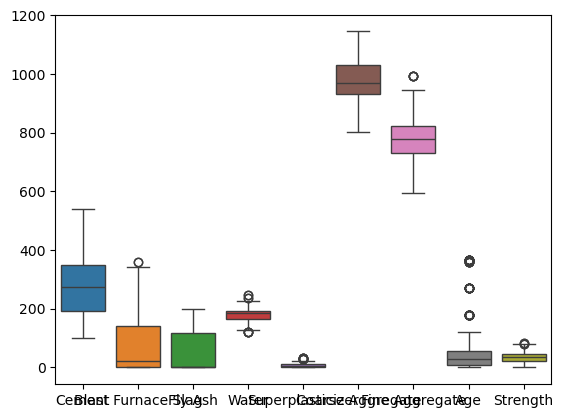

In [96]:
sns.boxplot(df)

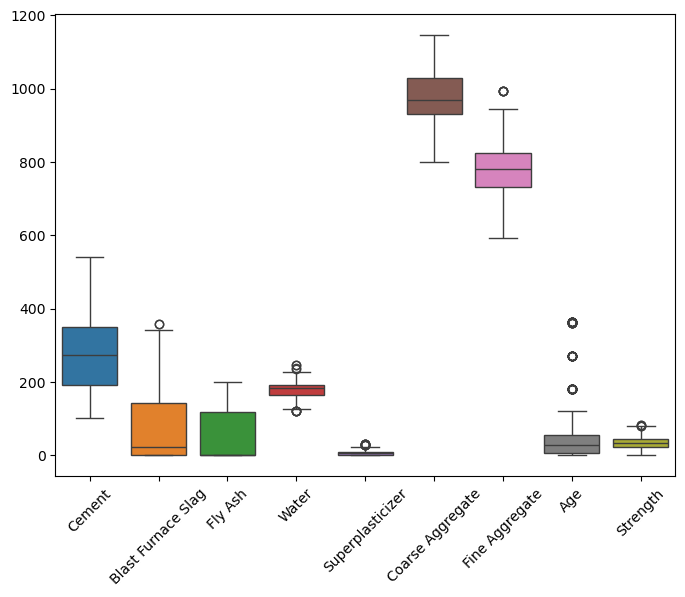

In [97]:
plt.figure(figsize = (8,6))
sns.boxplot(df)
plt.xticks(rotation = 45)
plt.show()

In [98]:
df.columns

Index(['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer',
       'Coarse Aggregate', 'Fine Aggregate', 'Age', 'Strength'],
      dtype='object')

In [99]:
cols = [ 'Blast Furnace Slag',  'Water', 'Superplasticizer', 'Fine Aggregate']

In [100]:
cols

['Blast Furnace Slag', 'Water', 'Superplasticizer', 'Fine Aggregate']

In [101]:
for c in cols :
    print(c)

Blast Furnace Slag
Water
Superplasticizer
Fine Aggregate


In [102]:
for c in cols :
    q1 = df[c].quantile(0.25)
    q3 = df[c].quantile(0.75)
    iqr = q3-q1
    lower = q1 - (1.5 *iqr )
    upper = q3 + (1.5 * iqr )
    df[c] = df[c].map(lambda x : lower if x < lower else upper if x > upper else x)

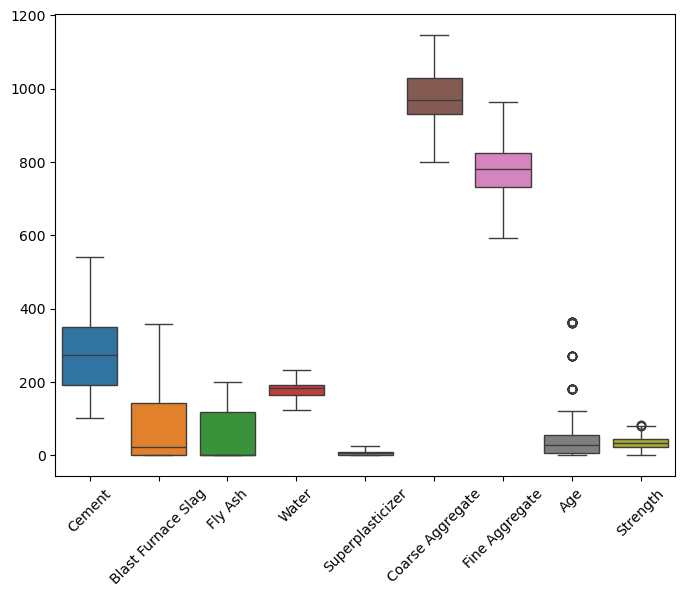

In [103]:
plt.figure(figsize = (8,6))
sns.boxplot(df)
plt.xticks(rotation = 45)
plt.show()

In [104]:
df["Age"]

0        28
1        28
2       270
3       365
4       360
       ... 
1025     28
1026     28
1027     28
1028     28
1029     28
Name: Age, Length: 1030, dtype: int64

In [105]:
q1_age = df["Age"].quantile(0.25)

In [106]:
q3_age = df["Age"].quantile(0.75)

In [107]:
iqr_age = q3_age - q1_age

In [108]:
lower_age = q1_age - (1.5 * iqr_age)

In [109]:
upper_age = q3_age + (1.5 * iqr_age)

In [110]:
lower_age

np.float64(-66.5)

In [111]:
upper_age

np.float64(129.5)

In [112]:
df[ df["Age"] < lower_age ]

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength


In [113]:
df[ df["Age"] > upper_age ]

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
6,380.0,95.0,0.0,228.0,0.0,932.0,594.0,365,43.70
12,427.5,47.5,0.0,228.0,0.0,932.0,594.0,270,43.01
17,342.0,38.0,0.0,228.0,0.0,932.0,670.0,365,56.14
19,475.0,0.0,0.0,228.0,0.0,932.0,594.0,180,42.62
20,427.5,47.5,0.0,228.0,0.0,932.0,594.0,180,41.84
23,139.6,209.4,0.0,192.0,0.0,1047.0,806.9,180,44.21
24,380.0,0.0,0.0,228.0,0.0,932.0,670.0,365,52.52


In [114]:
df[ df["Age"] > upper_age ].count()

Cement                59
Blast Furnace Slag    59
Fly Ash               59
Water                 59
Superplasticizer      59
Coarse Aggregate      59
Fine Aggregate        59
Age                   59
Strength              59
dtype: int64

## Capping

In [115]:
df["Age"] = df["Age"].map(lambda x : lower_age if x < lower_age else upper_age if x > upper_age else x)

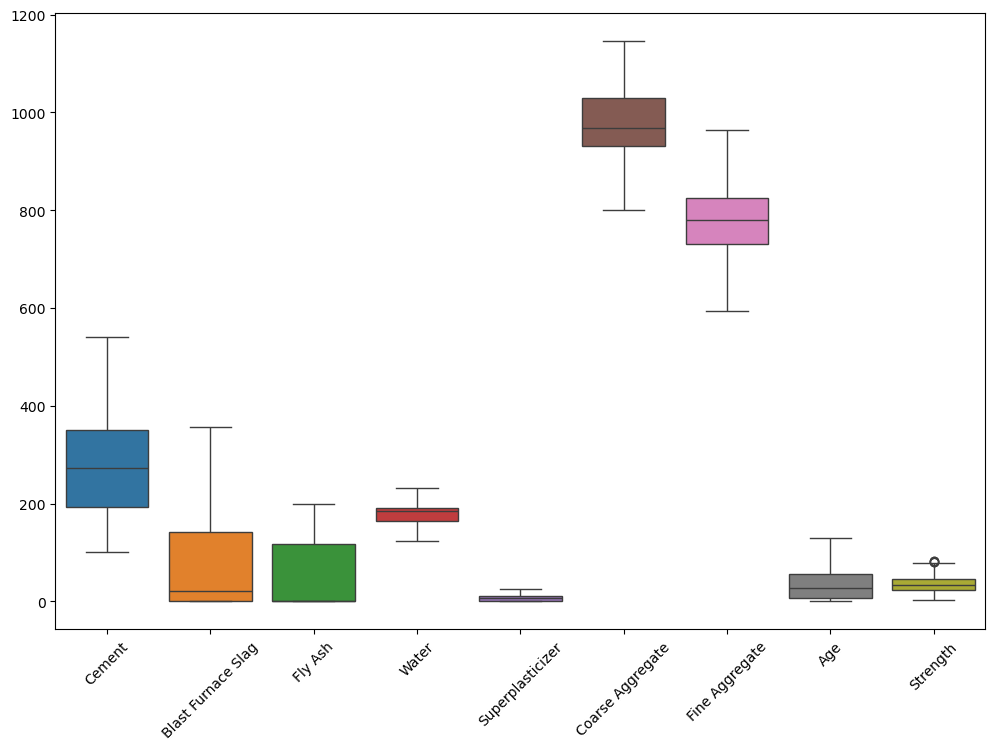

In [116]:
plt.figure(figsize = (12,8))
sns.boxplot(df)
plt.xticks(rotation = 45)
plt.show()

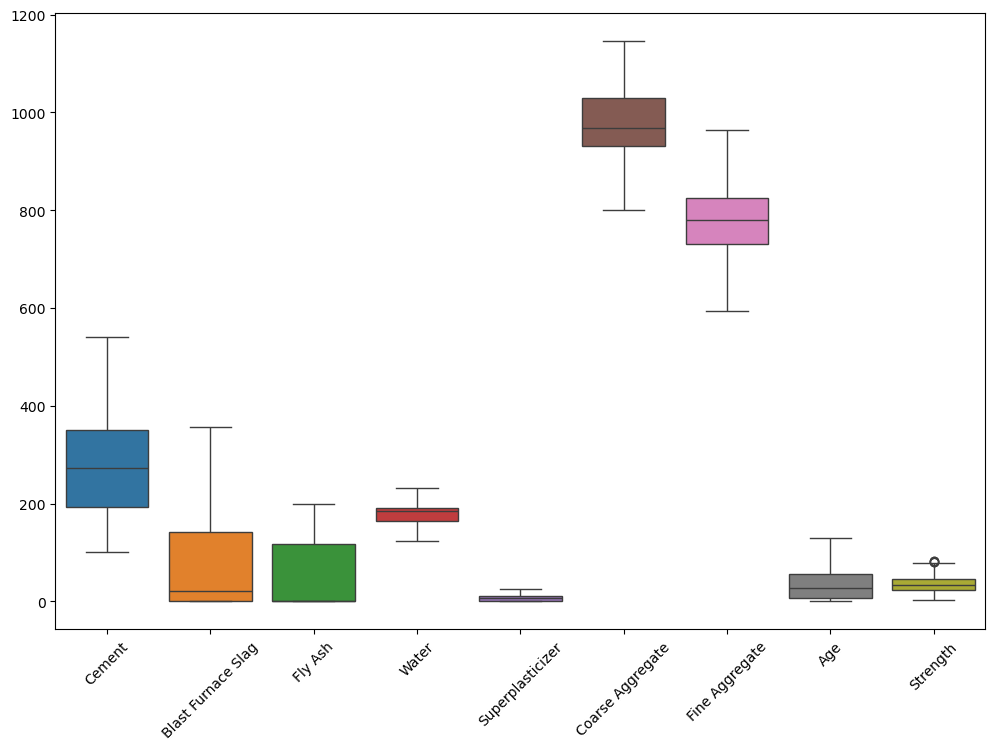

In [117]:
plt.figure(figsize = (12,8))
sns.boxplot(df)
plt.xticks(rotation = 45)
plt.show()

## Data Separation

In [118]:
df

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28.0,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28.0,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,129.5,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,129.5,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,129.5,44.30
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28.0,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28.0,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28.0,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28.0,32.77


In [119]:
df.drop("Strength",axis = 1)

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28.0
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28.0
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,129.5
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,129.5
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,129.5
...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28.0
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28.0
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28.0
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28.0


In [120]:
X = df.drop("Strength",axis = 1)

In [121]:
X

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28.0
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28.0
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,129.5
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,129.5
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,129.5
...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28.0
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28.0
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28.0
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28.0


In [122]:
y = df["Strength"]

In [123]:
y

0       79.99
1       61.89
2       40.27
3       41.05
4       44.30
        ...  
1025    44.28
1026    31.18
1027    23.70
1028    32.77
1029    32.40
Name: Strength, Length: 1030, dtype: float64

## Data Splitting

In [124]:
from sklearn.model_selection import train_test_split

In [125]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)

In [126]:
X.shape

(1030, 8)

In [127]:
X_train.shape

(824, 8)

In [128]:
X_test.shape

(206, 8)

## Model Building

In [129]:
from xgboost import XGBRegressor

In [130]:
xgb_model = XGBRegressor(n_estimators = 200)

In [131]:
xgb_model

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [132]:
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [133]:
xgb_model.score(X_test, y_test)

0.9157780766062062

## Cross validation

In [136]:
from sklearn.model_selection import cross_val_score

In [137]:
xgb_model1 = XGBRegressor(n_estimator = 200)

In [138]:
xgb_model1

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimator=200,
             n_estimators=None, n_jobs=None, ...)

In [139]:
score = cross_val_score(xgb_model1, X, y, cv = 20, n_jobs = -1)

In [140]:
score.mean()

np.float64(0.814647151632865)

# Ensemble Model Function

In [141]:
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor

In [142]:
def ensemble_model(X1, X2, y1, y2):
        rfc1 = RandomForestRegressor()
        ada1 = AdaBoostRegressor()
        xgb1 = XGBRegressor()
        models = [rfc1, ada1, xgb1]
        score= []
        for m in models :
            m.fit(X1, y1)
            sc = m.score(X2, y2)
            score.append(sc)
        print(score)
        return np.mean(score)

In [143]:
ensemble_model(X_train, X_test, y_train, y_test)

[0.8787267484736646, 0.7584043273347957, 0.9160947834778701]


np.float64(0.8510752864287768)

###  Auto ML

In [144]:
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor,GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression

In [145]:
rfr = RandomForestRegressor()
abr = AdaBoostRegressor()
gbr = GradientBoostingRegressor()
dtr = DecisionTreeRegressor()
svm = SVR()
knn = KNeighborsRegressor()
lr = LinearRegression()

In [146]:
models = [rfr, abr, gbr, dtr, svm, knn, lr]

In [147]:
models

[RandomForestRegressor(),
 AdaBoostRegressor(),
 GradientBoostingRegressor(),
 DecisionTreeRegressor(),
 SVR(),
 KNeighborsRegressor(),
 LinearRegression()]

In [148]:
for m in models:
    scores = cross_val_score(m, X, y, cv = 20, n_jobs = -1)
    scores.mean()
    print(m,"===>",scores.mean())

RandomForestRegressor() ===> 0.7827420391017774
AdaBoostRegressor() ===> 0.6005532809514013
GradientBoostingRegressor() ===> 0.7706380825926086
DecisionTreeRegressor() ===> 0.563109140664644
SVR() ===> -0.20973757238374086
KNeighborsRegressor() ===> 0.3246115669842806
LinearRegression() ===> 0.4677377337354024


## Evaluation Metrics:

In [149]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predictions
y_pred = xgb_model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 3.0613148034660562
MSE : 21.702043657414542
RMSE : 4.6585452297272525
R2 Score : 0.9157780766062062


## Visualization 

### 1. Correlation Heatmap

Shows relationships between cement ingredients and concrete strength.

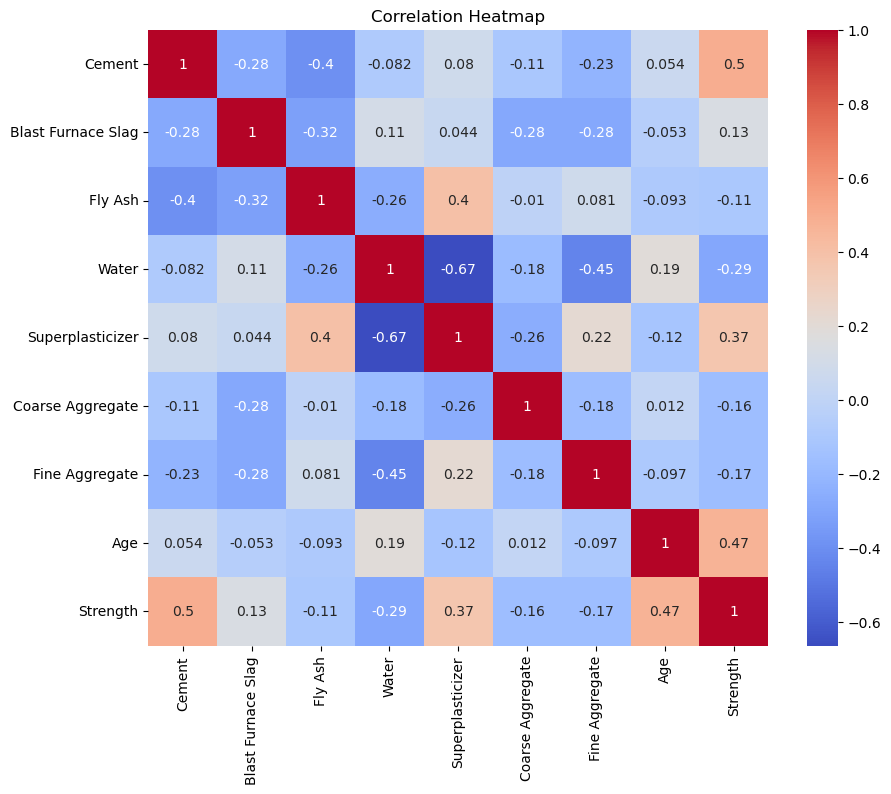

In [150]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

### 2. Feature Importance Graph

Shows which features affect concrete strength the most.

<Figure size 1000x600 with 0 Axes>

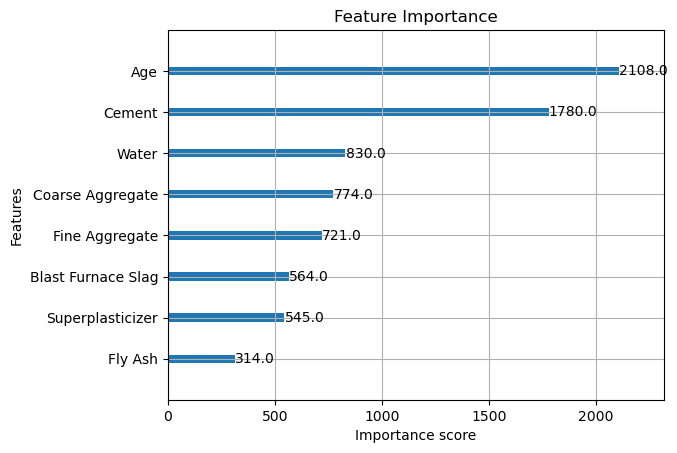

In [151]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plot_importance(xgb_model)

plt.title("Feature Importance")
plt.show()

### 3. Actual vs Predicted Values Scatter Plot

Compares actual concrete strength with predicted strength.

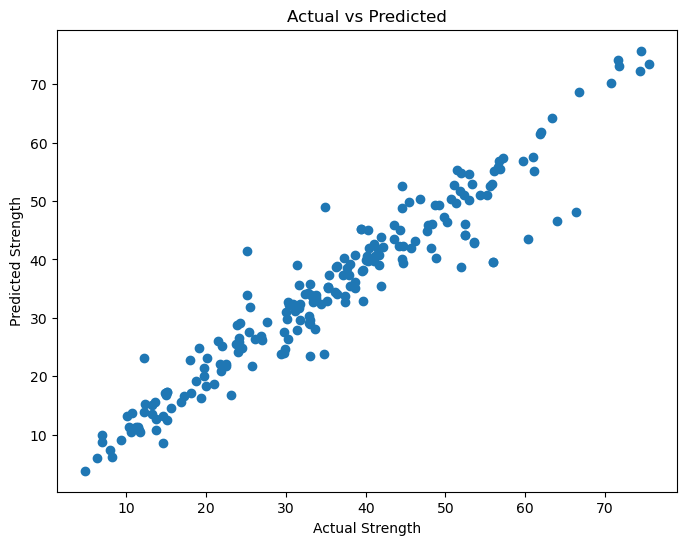

In [152]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Strength")
plt.ylabel("Predicted Strength")
plt.title("Actual vs Predicted")

plt.show()

### 4. Residual Error Plot

Shows prediction errors.

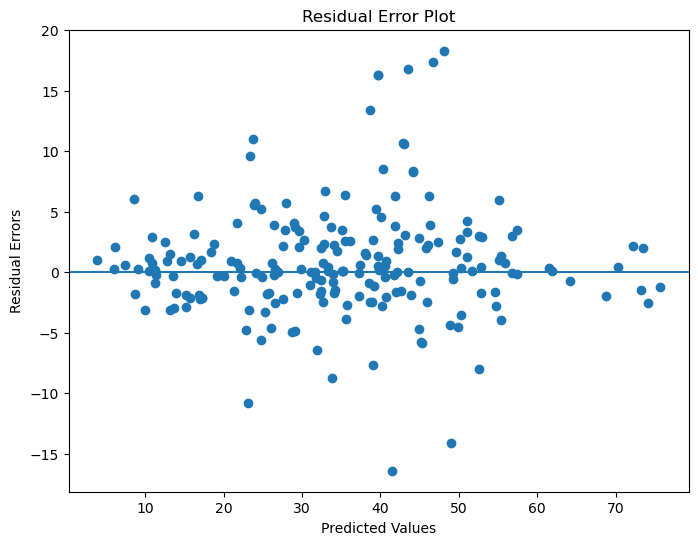

In [153]:
errors = y_test - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, errors)

plt.axhline(y=0)

plt.xlabel("Predicted Values")
plt.ylabel("Residual Errors")
plt.title("Residual Error Plot")

plt.show()

### 5. Distribution Plot of Concrete Strength

Shows strength value distribution.

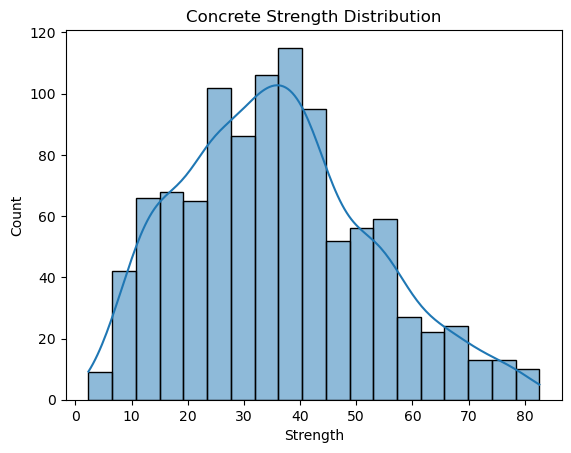

In [154]:
sns.histplot(df['Strength'], kde=True)

plt.title("Concrete Strength Distribution")
plt.show()

### 6.Evaluation Metrics Chart

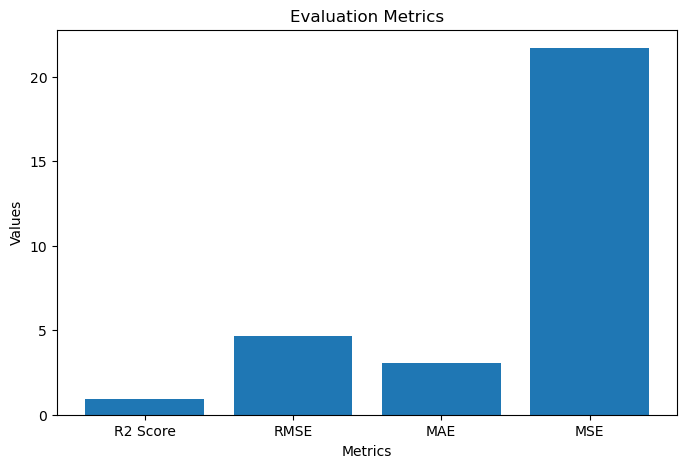

In [155]:
import matplotlib.pyplot as plt

metrics = ['R2 Score', 'RMSE', 'MAE', 'MSE']
values = [0.91, 4.65, 3.06, 21.70]

plt.figure(figsize=(8,5))
plt.bar(metrics, values)

plt.title("Evaluation Metrics")
plt.xlabel("Metrics")
plt.ylabel("Values")

plt.show()

## Model Save

In [156]:
import joblib
joblib.dump(xgb_model, "cement_model.pkl")

['cement_model.pkl']